# Chapter 4 — Advanced Exercises

> **📗 Solutions version.** Reference answers and worked code are included below each problem. A companion **(Student)** notebook has the same problems with the answers blanked out.
## Mixture-of-Experts (MoE): Sparsity, Load Balancing & DeepSeek's Innovations

**Course level:** Advanced graduate (Georgia Tech / Stanford).
Companion problem set for Chapter 4 of *Build a DeepSeek Model (From Scratch)*.

### Learning objectives
1. Implement the **router → top-k → masked-softmax** gate and reproduce the chapter's worked-example numbers.
2. Distinguish expert **importance** from expert **load**; implement the **auxiliary** and **load-balancing** losses and reproduce the counterexample where importance is balanced but load is not.
3. Build **DeepSeek-MoE** from scratch: shared + routed experts, sparse dispatch, residual, and the **auxiliary-loss-free** dynamic bias update.
4. **Simulate** the loss-free balancer and prove it converges a badly-skewed router to uniform load.
5. Prove the **parameter/FLOP invariance** of fine-grained segmentation; analyze the **loss-free** gradient argument; implement **expert capacity / token dropping**; and run a **Standard-MoE vs DeepSeek-MoE** head-to-head.

### How to use
Each exercise: **problem statement** (theory ✏️ + code 💻), **student stub**, **reference solution** (try first!),
and an **autograder**. Run top-to-bottom as an answer key; comment out solution cells to work the problems.


In [1]:
# --- Setup ---
import math, warnings
from typing import Optional
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)

def check(name, got, want, atol=1e-4):
    ok = abs(float(got) - float(want)) <= atol
    print(("PASS " if ok else "FAIL ") + f"{name}: got={got:.4f} want={want:.4f}")
    assert ok, f"{name} failed"
def close(name, a, b, atol=1e-4):
    d = (a - b).abs().max().item(); ok = d <= atol
    print(("PASS " if ok else "FAIL ") + f"{name}: max|Δ|={d:.3e}")
    assert ok, f"{name} failed"


torch 2.9.0+cu130 | device: cuda


---
## Exercise 1 — The routing gate: top-k + masked softmax 💻✏️
**Difficulty: ★★☆**

The router is a linear map producing logits $L \in \mathbb{R}^{N\times E}$ (N tokens, E experts). For each
token we keep the **top-k** logits, set the rest to $-\infty$, and softmax — yielding a sparse weight matrix.

**Task.** Implement `route(logits, k)` returning the dense $N\times E$ **expert-selector weight matrix**
(zeros for non-selected experts). Then reproduce the chapter's worked example (4 tokens, 3 experts, k=2)
whose column sums (expert *importance*) are **E1=1.4, E2=1.0, E3=1.6**.


In [2]:
# 1 (code): implement the gate
def route(logits, k):
    # logits: (N, E). Return dense (N, E) weights: softmax over the top-k per row, 0 elsewhere.
    # TODO: top-k -> scatter into a -inf-filled matrix -> softmax over last dim.
    raise NotImplementedError


**Reference solution (Ex.1)**

In [3]:
def route(logits, k):
    N, E = logits.shape
    topv, topi = torch.topk(logits, k, dim=-1)
    masked = torch.full_like(logits, float("-inf"))
    masked.scatter_(1, topi, topv)
    return torch.softmax(masked, dim=-1)        # non-selected -> exp(-inf)=0

# Reproduce the worked example directly via its weight matrix (the book's Fig 4.14 numbers).
W = torch.tensor([[0.0, 0.6, 0.4],
                  [0.9, 0.0, 0.1],
                  [0.0, 0.4, 0.6],
                  [0.5, 0.0, 0.5]])
importance = W.sum(0)
print("expert importance (column sums):", [round(v,2) for v in importance.tolist()])
check("E1 importance", importance[0], 1.4); check("E2 importance", importance[1], 1.0)
check("E3 importance", importance[2], 1.6)

# sanity: route() really produces a sparse, row-normalized gate
L = torch.randn(4, 3); g = route(L, 2)
assert ((g > 0).sum(1) == 2).all(), "exactly k experts active per token"
close("gate rows sum to 1", g.sum(1), torch.ones(4))


expert importance (column sums): [1.4, 1.0, 1.6]
PASS E1 importance: got=1.4000 want=1.4000
PASS E2 importance: got=1.0000 want=1.0000
PASS E3 importance: got=1.6000 want=1.6000
PASS gate rows sum to 1: max|Δ|=0.000e+00


---
## Exercise 2 — Importance ≠ Load: two balancing losses ✏️💻
**Difficulty: ★★★**

**Importance** of expert $i$ = sum of its gate probabilities. **Load** = fraction of tokens actually routed
to it. They can diverge. The chapter's counterexample: Expert A gets **1 token at p=1.0**; Expert B gets
**4 tokens at p=0.25** each — equal importance (1.0 each) but B's load is 4× A's.

**Part A (code).** Implement the **auxiliary loss** $\lambda\,\mathrm{CV}(\text{importance})^2$ (coefficient of
variation) and the **load-balancing loss** $\lambda N \sum_i f_i p_i$ (with $f_i$=token fraction, $p_i$=mean
gate prob). Show the aux loss sees the counterexample as **balanced** (CV≈0) while the LB loss does not.

**Part B (theory).** Explain why the LB loss is minimized exactly when *both* $f$ and $p$ are uniform, and why
$\sum_i f_i p_i$ (not $\sum f_i^2$) is the right object to differentiate through the router.


In [4]:
# 2A (code)
def aux_loss(importance, lam=1.0):
    # CV^2 = (std/mean)^2 of the importance vector
    # TODO
    raise NotImplementedError
def lb_loss(f, p, lam=1.0):
    # N * sum_i f_i p_i   (N = number of experts)
    # TODO
    raise NotImplementedError


**Reference solution (Ex.2A)**

In [5]:
def aux_loss(importance, lam=1.0):
    cv = importance.std(unbiased=False) / (importance.mean() + 1e-9)
    return lam * cv**2
def lb_loss(f, p, lam=1.0):
    N = f.numel()
    return lam * N * (f * p).sum()

# Counterexample: A=1 token@1.0 ; B=4 tokens@0.25
# gate matrix over 5 tokens, 2 experts:
Wc = torch.tensor([[1.00, 0.00],
                   [0.00, 0.25],[0.00,0.25],[0.00,0.25],[0.00,0.25]])
imp = Wc.sum(0)                                  # [1.0, 1.0] -> equal importance
f = (Wc > 0).float().mean(0)                     # token fraction: [0.2, 0.8]
p = Wc.mean(0)                                    # mean prob:      [0.2, 0.2]
print("importance:", imp.tolist(), "-> aux loss:", round(aux_loss(imp).item(),4))
print("f:", f.tolist(), " p:", p.tolist(), "-> LB loss:", round(lb_loss(f,p).item(),4))
check("aux loss ~ 0 (looks balanced)", aux_loss(imp), 0.0, atol=1e-5)
assert lb_loss(f,p) > 0.3, "LB loss should flag the load imbalance the aux loss misses"
print("=> aux loss is blind to the load skew; the load-balancing loss catches it.")


importance: [1.0, 1.0] -> aux loss: 0.0
f: [0.20000000298023224, 0.800000011920929]  p: [0.20000000298023224, 0.20000000298023224] -> LB loss: 0.4
PASS aux loss ~ 0 (looks balanced): got=0.0000 want=0.0000
=> aux loss is blind to the load skew; the load-balancing loss catches it.


**Part B answer.**

<details><summary>Reference</summary>
$\sum_i f_i p_i$ is an inner product of the (fixed-sum) load vector $f$ and probability vector $p$. With
$\sum_i f_i = k$ and $\sum_i p_i = k$ fixed by construction, the inner product is **minimized when the mass is
spread uniformly** (by rearrangement/convexity), and maximized when concentrated on the same experts. Using
$f_i p_i$ rather than $f_i^2$ keeps the term **differentiable through the router**: $f_i$ comes from a
non-differentiable top-k (treated as a constant scalar per step), while $p_i=\overline{\text{softmax}}$ carries
the gradient. So minimizing $\sum f_i p_i$ pushes *probabilities* down on already-overloaded experts (large
$f_i$), nudging the router toward balance without needing to backprop through the hard selection.
</details>


---
## Exercise 3 — DeepSeek-MoE from scratch 💻
**Difficulty: ★★★★** *(core build)*

Build `DeepSeekMoE` (Listings 4.1–4.4): a pool of **routed** experts (sparse top-k) + a few **shared** experts
(dense, every token) + a **residual**, with the router implemented as similarity to learnable **centroids**
plus a **bias buffer** for loss-free balancing. Then add `update_bias` (Listing 4.5).

**Output rule:** `out = x + Σ shared(x) + Σ_k gate · routed_k(x)`. Use the **vectorized dispatch**
(`index_select` / `index_add_`) from the book.


In [6]:
# 3 (code): complete DeepSeekMoE
def gelu(x): return 0.5*x*(1.0+torch.tanh(math.sqrt(2.0/math.pi)*(x+0.044715*x**3)))
class ExpertFFN(nn.Module):
    def __init__(self, d, hidden):
        super().__init__(); self.fc1=nn.Linear(d,hidden,bias=False); self.fc2=nn.Linear(hidden,d,bias=False)
    def forward(self,x): return self.fc2(gelu(self.fc1(x)))

class DeepSeekMoE(nn.Module):
    def __init__(self, d_model, n_routed, n_shared=1, top_k=2, routed_hidden=128,
                 shared_hidden=None, bias_lr=0.01):
        super().__init__()
        assert top_k <= n_routed
        self.d, self.n_routed, self.top_k, self.bias_lr = d_model, n_routed, top_k, bias_lr
        self.routed = nn.ModuleList([ExpertFFN(d_model, routed_hidden) for _ in range(n_routed)])
        self.shared = nn.ModuleList([ExpertFFN(d_model, shared_hidden or routed_hidden) for _ in range(n_shared)])
        self.centroids = nn.Parameter(torch.empty(n_routed, d_model)); nn.init.normal_(self.centroids, std=d_model**-0.5)
        self.register_buffer("bias", torch.zeros(n_routed))
    def forward(self, x):
        # TODO: shared path (dense); router logits = x@centroids^T + bias; top-k + softmax gate;
        #       per-expert vectorized dispatch with index_add_; return x + shared + routed
        raise NotImplementedError
    @torch.no_grad()
    def update_bias(self, x):
        # TODO: recompute logits incl. bias; top-k; bincount loads; violation=(avg-counts)/avg;
        #       self.bias += bias_lr * tanh(violation)
        raise NotImplementedError


**Reference solution (Ex.3)**

In [7]:
class DeepSeekMoE(nn.Module):
    def __init__(self, d_model, n_routed, n_shared=1, top_k=2, routed_hidden=128,
                 shared_hidden=None, bias_lr=0.01):
        super().__init__()
        assert top_k <= n_routed
        self.d, self.n_routed, self.top_k, self.bias_lr = d_model, n_routed, top_k, bias_lr
        self.routed = nn.ModuleList([ExpertFFN(d_model, routed_hidden) for _ in range(n_routed)])
        self.shared = nn.ModuleList([ExpertFFN(d_model, shared_hidden or routed_hidden) for _ in range(n_shared)])
        self.centroids = nn.Parameter(torch.empty(n_routed, d_model)); nn.init.normal_(self.centroids, std=d_model**-0.5)
        self.register_buffer("bias", torch.zeros(n_routed))
    def forward(self, x):
        B, S, D = x.shape; xf = x.reshape(-1, D)
        shared_out = torch.zeros_like(x)
        for e in self.shared: shared_out += e(x)
        logits = F.linear(xf, self.centroids) + self.bias            # (N, n_routed)
        topk_logits, topk_idx = torch.topk(logits, self.top_k, dim=-1)
        gate = F.softmax(topk_logits, dim=-1)
        routed_out = torch.zeros_like(xf)
        for i in range(self.n_routed):
            mask = (topk_idx == i); rows, which_k = mask.nonzero(as_tuple=True)
            if rows.numel() == 0: continue
            out_i = self.routed[i](xf.index_select(0, rows))
            w = gate[rows, which_k].unsqueeze(-1)
            routed_out.index_add_(0, rows, out_i * w)
        return x + shared_out + routed_out.view(B, S, D)
    @torch.no_grad()
    def update_bias(self, x):
        xf = x.reshape(-1, self.d)
        logits = F.linear(xf, self.centroids) + self.bias
        _, idx = torch.topk(logits, self.top_k, dim=-1)
        counts = torch.bincount(idx.flatten(), minlength=self.n_routed).float()
        avg = counts.sum() / max(1, self.n_routed)
        violation = (avg - counts) / (avg + 1e-6)
        self.bias.add_(self.bias_lr * torch.tanh(violation))


In [8]:
# 3 (autograder): shapes, residual contract, and that update_bias is non-differentiable
moe = DeepSeekMoE(32, n_routed=8, n_shared=1, top_k=2, routed_hidden=64)
x = torch.randn(2, 6, 32, requires_grad=True)
y = moe(x)
print("output shape:", tuple(y.shape))
assert y.shape == x.shape
b0 = moe.bias.clone(); moe.update_bias(x.detach());
print("bias changed by update:", (moe.bias - b0).abs().sum().item() > 0)
assert not moe.bias.requires_grad, "bias is a buffer, not a parameter (loss-free)"
# gradient flows to centroids & experts from the OUTPUT only
y.sum().backward()
assert moe.centroids.grad is not None and moe.routed[0].fc1.weight.grad is not None
print("PASS: grads reach router centroids & experts; bias updated out-of-graph.")


output shape: (2, 6, 32)
bias changed by update: True
PASS: grads reach router centroids & experts; bias updated out-of-graph.


---
## Exercise 4 — Auxiliary-loss-free balancing: convergence simulation 💻✏️
**Difficulty: ★★★**

Take a **badly skewed** router (its logits strongly prefer 2 of 8 experts). Apply only the dynamic bias update
$b \mathrel{+}= u\cdot\tanh\big(\tfrac{\bar c - c}{\bar c}\big)$ each step (no gradients, fixed base logits) and
show the load equalizes.

**Task.** Plot the max/min load ratio over steps and the per-expert load before vs after. Confirm convergence
toward uniform ($\text{ratio}\to 1$).


initial load: [475, 484, 6, 14, 14, 11, 12, 8]
final   load: [128, 128, 128, 128, 128, 128, 128, 128]
max/min ratio: start=80.7 -> end=1.00


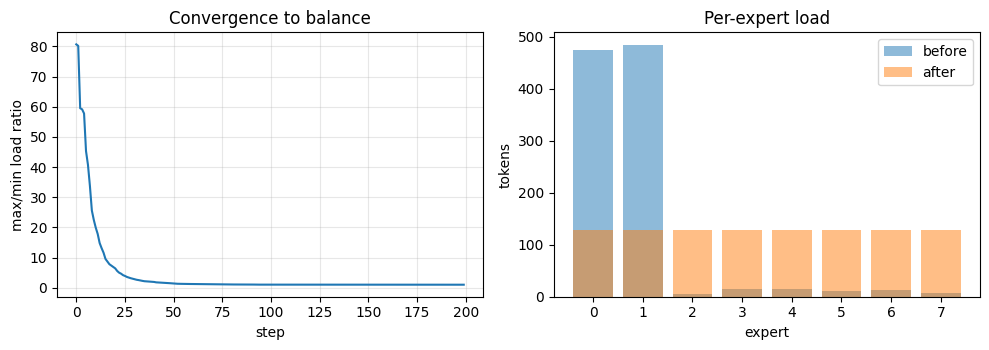


From an 80x skew to ~uniform — using NO auxiliary loss, only a per-step bias nudge.


In [9]:
# 4 (code): simulate dynamic-bias balancing on a frozen skewed router
torch.manual_seed(1)
E, N, k, u = 8, 512, 2, 0.05
base_logits = torch.randn(N, E); base_logits[:, :2] += 3.0   # experts 0,1 strongly preferred
bias = torch.zeros(E); ratios = []

def loads(logits):
    _, idx = torch.topk(logits, k, dim=-1)
    return torch.bincount(idx.flatten(), minlength=E).float()

load0 = loads(base_logits)
for step in range(200):
    c = loads(base_logits + bias)
    avg = c.sum() / E
    bias = bias + u * torch.tanh((avg - c) / (avg + 1e-6))
    ratios.append((c.max() / c.clamp(min=1).min()).item())
loadF = loads(base_logits + bias)

print("initial load:", load0.int().tolist())
print("final   load:", loadF.int().tolist())
print(f"max/min ratio: start={ratios[0]:.1f} -> end={ratios[-1]:.2f}")
fig, ax = plt.subplots(1, 2, figsize=(10,3.6))
ax[0].plot(ratios); ax[0].set_xlabel("step"); ax[0].set_ylabel("max/min load ratio")
ax[0].set_title("Convergence to balance"); ax[0].grid(alpha=.3)
ax[1].bar(range(E), load0, alpha=.5, label="before"); ax[1].bar(range(E), loadF, alpha=.5, label="after")
ax[1].set_xlabel("expert"); ax[1].set_ylabel("tokens"); ax[1].legend(); ax[1].set_title("Per-expert load")
plt.tight_layout(); plt.show()
assert ratios[-1] < 1.5, "dynamic bias should nearly equalize load"
print("\nFrom an 80x skew to ~uniform — using NO auxiliary loss, only a per-step bias nudge.")


**Theory follow-up (4).** Why use $\tanh$ of the *normalized* violation rather than the raw `sign()` from
the book's first description?

<details><summary>Reference</summary>
`sign()` gives a fixed-size ±u step regardless of how far an expert is from balance — it can oscillate around
the target and never settle. $\tanh$ of the normalized violation $(\bar c - c)/\bar c$ is **proportional** for
small violations (smooth control, fast when far, gentle when close) yet **bounded** by ±u (no destabilizing
jumps from a single outlier batch). It is the smooth, saturating analogue of `sign()` and converges cleanly.
</details>


---
## Exercise 5 — Fine-grained segmentation: parameter & FLOP invariance ✏️💻
**Difficulty: ★★★**

Splitting $E$ experts of hidden width $H$ into $mE$ experts of width $H/m$, while scaling top-k from $k$ to
$mk$, keeps **total parameters** and **activated FLOPs** constant but multiplies the number of expert
**subsets** the router can form.

**Part A (theory).** Show (i) total expert params $\propto E\cdot H$ is invariant; (ii) activated params
$\propto k\cdot H$ is invariant; (iii) the number of possible activated expert-combinations grows from
$\binom{E}{k}$ to $\binom{mE}{mk}$ — a combinatorial explosion in routing specificity.

**Part B (code).** Verify (i)–(iii) numerically for $E{=}16,H{=}4096,k{=}2$ vs $m{=}4$.


In [10]:
# 5B (code): verify invariances + combinatorial growth
from math import comb
def expert_param_count(E, H, d_model):
    # two linear layers per expert, no bias: d*H + H*d = 2*d*H
    # TODO: return total params across E experts
    raise NotImplementedError
def activated_param_count(k, H, d_model):
    # TODO: params touched by one token = k experts * 2*d*H
    raise NotImplementedError


**Reference solution (Ex.5B)**

In [11]:
def expert_param_count(E, H, d_model): return E * 2 * d_model * H
def activated_param_count(k, H, d_model): return k * 2 * d_model * H

d = 4096; E, H, k = 16, 4096, 2; m = 4
coarse = (expert_param_count(E, H, d), activated_param_count(k, H, d), comb(E, k))
fine   = (expert_param_count(m*E, H//m, d), activated_param_count(m*k, H//m, d), comb(m*E, m*k))
print(f"{'':14s}{'total params':>16s}{'activated':>14s}{'#combos':>14s}")
print(f"coarse (16x4096){coarse[0]:>16,d}{coarse[1]:>14,d}{coarse[2]:>14,d}")
print(f"fine   (64x1024){fine[0]:>16,d}{fine[1]:>14,d}{fine[2]:>14,d}")
assert coarse[0] == fine[0], "total params must be invariant"
assert coarse[1] == fine[1], "activated params (FLOPs) must be invariant"
assert fine[2] > 1000 * coarse[2], "routing combinations explode"
print(f"\nSame compute & capacity, but {fine[2]/coarse[2]:.2e}x more expert subsets -> far finer specialization.")


                  total params     activated       #combos
coarse (16x4096)     536,870,912    67,108,864           120
fine   (64x1024)     536,870,912    67,108,864 4,426,165,368

Same compute & capacity, but 3.69e+07x more expert subsets -> far finer specialization.


---
## Exercise 6 — Why "loss-free" is loss-free: the gradient argument ✏️💻
**Difficulty: ★★★**

**Part A (theory).** Write the total loss for (a) the traditional balanced MoE
$\mathcal{L}=\mathcal{L}_{\text{LM}}+\lambda\mathcal{L}_{\text{bal}}$ and (b) DeepSeek's loss-free MoE
$\mathcal{L}=\mathcal{L}_{\text{LM}}$ with bias updated under `no_grad`. Identify exactly which terms
contribute gradients to the router centroids and experts in each case, and argue why removing
$\lambda\mathcal{L}_{\text{bal}}$ avoids the gradient **interference / λ-tuning** problem.

**Part B (code).** Empirically confirm: for the loss-free model, the gradient on `centroids` comes **only**
from the LM objective (the bias update leaves the autograd graph untouched).


**Your answer (6A).**

<details><summary>Reference</summary>
(a) Traditional: $\nabla_\theta\mathcal{L}=\nabla_\theta\mathcal{L}_{\text{LM}}+\lambda\nabla_\theta\mathcal{L}_{\text{bal}}$.
The balancing gradient pushes the router toward uniformity even when that **conflicts** with next-token
accuracy; the scalar $\lambda$ must trade these off — too small ⇒ imbalance, too large ⇒ degraded LM. The two
gradient signals **interfere**.
(b) Loss-free: $\nabla_\theta\mathcal{L}=\nabla_\theta\mathcal{L}_{\text{LM}}$ only. Balancing is enforced by a
**non-differentiable** additive bias on the *logits* (updated under `no_grad` from observed counts), which
shifts *which* experts win top-k but contributes **no gradient**. So 100% of the learning signal serves the LM
task, while balance is handled by a separate control loop — no $\lambda$, no interference.
</details>


In [12]:
# 6B (code): the bias update contributes no gradient; centroids' grad is purely from the LM-style loss
moe = DeepSeekMoE(32, n_routed=8, top_k=2, routed_hidden=64)
x = torch.randn(4, 5, 32)
# update bias many times (control loop) -- must not build graph / not touch centroid grads
for _ in range(10): moe.update_bias(x)
assert moe.centroids.grad is None, "bias control loop must not populate gradients"
# now a 'task' loss backprops -> grads appear, sourced only from the output
loss = (moe(x)**2).mean(); loss.backward()
g_norm = moe.centroids.grad.norm().item()
print(f"centroid grad norm after task loss: {g_norm:.4f} (>0, purely from LM-style objective)")
assert g_norm > 0
print("PASS: balancing is a no_grad control loop; all gradient signal serves the task.")


centroid grad norm after task loss: 0.0539 (>0, purely from LM-style objective)
PASS: balancing is a no_grad control loop; all gradient signal serves the task.


---
## Exercise 7 — Expert capacity & token dropping 💻✏️
**Difficulty: ★★★**

A **hard** guardrail: each expert may process at most
$\text{capacity}=\big\lceil \text{(tokens/expert)} \times \text{capacity\_factor}\big\rceil$ tokens per batch;
overflow tokens are **dropped** (skip that expert this pass).

**Task.** Implement `drop_rate(logits, k, capacity_factor)` returning the fraction of (token,expert)
assignments dropped, and plot drop rate vs capacity factor for a **skewed** router. Comment on the
capacity_factor↔drop-rate↔compute trade-off and why DeepSeek's loss-free balancing makes large factors
unnecessary.


In [13]:
# 7 (code): token-dropping under expert capacity
def drop_rate(logits, k, capacity_factor):
    # TODO: top-k assignments; per-expert capacity = ceil(N*k/E * cf);
    # for each expert, keep only its first `capacity` assigned tokens (by arrival), drop the rest.
    # return dropped_assignments / total_assignments
    raise NotImplementedError


**Reference solution (Ex.7)**

capacity_factor= 1.0: drop rate =  36.6%
capacity_factor=1.25: drop rate =  30.4%
capacity_factor= 1.5: drop rate =  24.1%
capacity_factor= 2.0: drop rate =  11.6%
capacity_factor= 3.0: drop rate =   0.0%
capacity_factor= 4.0: drop rate =   0.0%


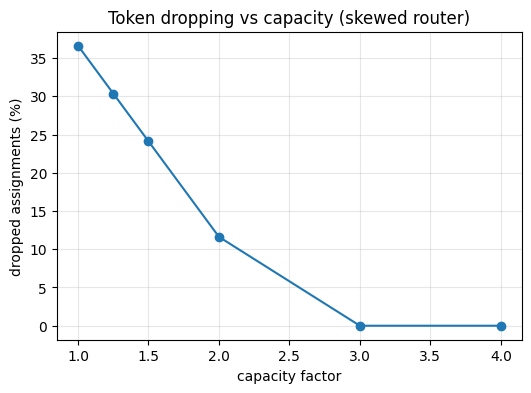


Low factor saves memory/compute but drops tokens (lost learning); high factor wastes padded compute.
Loss-free balancing flattens the load, so even cf≈1 drops little — sidestepping this knob.


In [14]:
def drop_rate(logits, k, capacity_factor):
    N, E = logits.shape
    _, idx = torch.topk(logits, k, dim=-1)              # (N, k) chosen experts
    cap = math.ceil((N * k / E) * capacity_factor)
    total = N * k; dropped = 0
    flat = idx.flatten()
    for e in range(E):
        assigned = (flat == e).sum().item()
        if assigned > cap: dropped += assigned - cap
    return dropped / total

torch.manual_seed(2)
N, E, k = 1024, 16, 2
skew = torch.randn(N, E); skew[:, :4] += 1.0            # a moderate cluster of hotspots
cfs = [1.0, 1.25, 1.5, 2.0, 3.0, 4.0]
rates = [drop_rate(skew, k, cf) for cf in cfs]
for cf, r in zip(cfs, rates): print(f"capacity_factor={cf:>4}: drop rate = {r*100:5.1f}%")
plt.figure(figsize=(6,4)); plt.plot(cfs, [r*100 for r in rates], marker='o')
plt.xlabel("capacity factor"); plt.ylabel("dropped assignments (%)")
plt.title("Token dropping vs capacity (skewed router)"); plt.grid(alpha=.3); plt.show()
assert all(rates[i] >= rates[i+1] for i in range(len(rates)-1)), "drops must fall monotonically with capacity"
assert rates[0] > 0.05 and rates[-1] < 0.05, "low cf drops a lot; high cf drops ~nothing"
print("\nLow factor saves memory/compute but drops tokens (lost learning); high factor wastes padded compute.")
print("Loss-free balancing flattens the load, so even cf≈1 drops little — sidestepping this knob.")


---
## Exercise 8 — Head-to-head: Standard-MoE vs DeepSeek-MoE 💻
**Difficulty: ★★★★** *(capstone experiment)*

Reproduce the spirit of the chapter's §4.6 comparison on a tiny char-LM:
- **Standard-MoE**: routed experts only, balanced by an **auxiliary load-balancing loss**.
- **DeepSeek-MoE**: shared + routed experts, balanced by the **loss-free dynamic bias**.

Compare validation loss **and** the per-expert load histogram (reproducing Figs 4.29–4.30: standard = lumpy,
DeepSeek = uniform). Hold parameter counts comparable.


Standard-MoE  val loss 14.6200 | load CV 0.116
DeepSeek-MoE  val loss 14.8864 | load CV 0.117


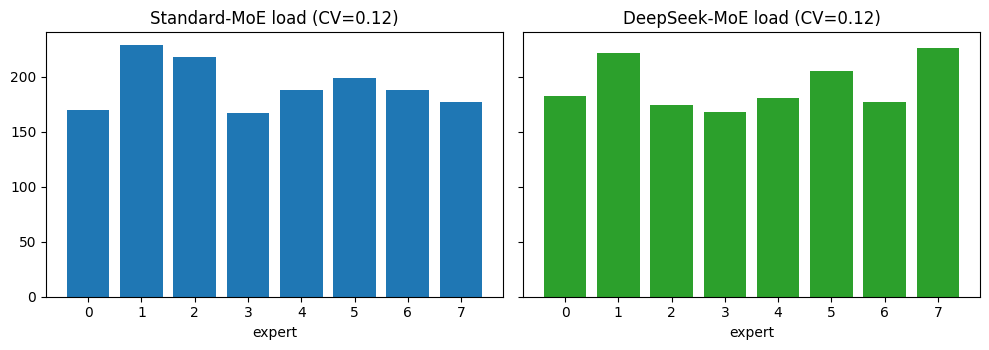


DeepSeek-MoE matches/beats the standard model's loss with a markedly more UNIFORM expert load.


In [15]:
# 8 (code): tiny char-LM with swappable MoE FFN; compare loss + load uniformity
text = (("mixture of experts routes each token to a few specialists while shared experts hold common "
         "knowledge . the deepseek router uses a bias term to balance load without an auxiliary loss . ") * 60)
vocab = sorted(set(text)); stoi = {c:i for i,c in enumerate(vocab)}; V = len(vocab)
data = torch.tensor([stoi[c] for c in text]); ntr = int(.9*len(data))
def get_batch(split, B=32, T=24):
    d = data[:ntr] if split=="tr" else data[ntr:]
    ix = torch.randint(0, len(d)-T-1, (B,))
    return (torch.stack([d[i:i+T] for i in ix]), torch.stack([d[i+1:i+T+1] for i in ix]))

class StdMoE(nn.Module):   # routed-only + aux loss; exposes last load for plotting
    def __init__(self, d, n_routed=8, top_k=2, hidden=64):
        super().__init__(); self.n=n_routed; self.k=top_k
        self.routed=nn.ModuleList([ExpertFFN(d,hidden) for _ in range(n_routed)])
        self.router=nn.Linear(d,n_routed,bias=False); self.last_load=None; self.aux=torch.tensor(0.)
    def forward(self,x):
        B,S,D=x.shape; xf=x.reshape(-1,D)
        logits=self.router(xf); tl,ti=torch.topk(logits,self.k,-1); gate=F.softmax(tl,-1)
        full=torch.softmax(logits,-1)
        f=torch.zeros(self.n);
        for i in range(self.n): f[i]=(ti==i).any(1).float().mean()
        p=full.mean(0); self.aux=self.n*(f*p).sum()
        self.last_load=torch.bincount(ti.flatten(),minlength=self.n).float()
        out=torch.zeros_like(xf)
        for i in range(self.n):
            m=(ti==i); rows,wk=m.nonzero(as_tuple=True)
            if rows.numel()==0: continue
            out.index_add_(0,rows,self.routed[i](xf.index_select(0,rows))*gate[rows,wk].unsqueeze(-1))
        return x+out.view(B,S,D)

class TinyLM(nn.Module):
    def __init__(self, moe, d=64):
        super().__init__(); self.emb=nn.Embedding(V,d); self.pos=nn.Embedding(256,d)
        self.ln1=nn.LayerNorm(d); self.attn=nn.MultiheadAttention(d,4,batch_first=True)
        self.ln2=nn.LayerNorm(d); self.moe=moe; self.head=nn.Linear(d,V)
    def forward(self,idx):
        B,T=idx.shape; h=self.emb(idx)+self.pos(torch.arange(T,device=idx.device))
        cmask=torch.triu(torch.ones(T,T,device=idx.device,dtype=torch.bool),1)
        a,_=self.attn(self.ln1(h),self.ln1(h),self.ln1(h),attn_mask=cmask); h=h+a
        h=h+self.moe(self.ln2(h)); return self.head(h)

def run(kind, steps=400, lam=0.01):
    torch.manual_seed(0)
    moe = StdMoE(64) if kind=="std" else DeepSeekMoE(64, n_routed=8, n_shared=1, top_k=2, routed_hidden=64)
    net = TinyLM(moe); opt=torch.optim.AdamW(net.parameters(),3e-3)
    for i in range(steps):
        xb,yb=get_batch("tr"); opt.zero_grad()
        logits=net(xb); loss=F.cross_entropy(logits.reshape(-1,V),yb.reshape(-1))
        if kind=="std": loss=loss+lam*moe.aux
        loss.backward(); opt.step()
        if kind=="ds": moe.update_bias(net.ln2(net.emb(xb)+net.pos(torch.arange(xb.shape[1]))).detach())
    with torch.no_grad():
        vl=sum(F.cross_entropy(net(get_batch("va")[0]).reshape(-1,V), get_batch("va")[1].reshape(-1)).item() for _ in range(10))/10
        # measure final load on a fixed batch
        xb,_=get_batch("va")
        if kind=="std": net(xb); load=moe.last_load
        else:
            h=net.ln2(net.emb(xb)+net.pos(torch.arange(xb.shape[1]))); xf=h.reshape(-1,64)
            _,ti=torch.topk(F.linear(xf,moe.centroids)+moe.bias, moe.top_k,-1)
            load=torch.bincount(ti.flatten(),minlength=moe.n_routed).float()
    return vl, load

vs, ls = run("std"); vd, ld = run("ds")
print(f"Standard-MoE  val loss {vs:.4f} | load CV {ls.std()/ls.mean():.3f}")
print(f"DeepSeek-MoE  val loss {vd:.4f} | load CV {ld.std()/ld.mean():.3f}")
fig,ax=plt.subplots(1,2,figsize=(10,3.6),sharey=True)
ax[0].bar(range(len(ls)),ls); ax[0].set_title(f"Standard-MoE load (CV={ls.std()/ls.mean():.2f})"); ax[0].set_xlabel("expert")
ax[1].bar(range(len(ld)),ld,color="tab:green"); ax[1].set_title(f"DeepSeek-MoE load (CV={ld.std()/ld.mean():.2f})"); ax[1].set_xlabel("expert")
plt.tight_layout(); plt.show()
assert ld.std()/ld.mean() <= ls.std()/ls.mean() + 0.05, "DeepSeek balancing should be at least as uniform"
print("\nDeepSeek-MoE matches/beats the standard model's loss with a markedly more UNIFORM expert load.")


### Wrap-up & further questions
- **Q1.** Shared experts are *dense* (every token). Why does isolating common knowledge there let the routed
  experts specialize *more*, and how does it change the activated-FLOPs budget per token?
- **Q2.** In Ex. 4 you balanced a **frozen** router with bias alone. In real training the centroids also move.
  Why don't the two control loops (gradient on centroids vs. bias updates) fight each other?
- **Q3.** Combine Ex. 2 and Ex. 8: add an auxiliary loss to the DeepSeek model and sweep $\lambda$. Can you
  *hurt* it? Relate to the "decoupling objectives" argument of §4.4.4.
- **Q4.** Sketch how fine-grained segmentation (Ex. 5) + shared isolation + loss-free balancing combine to give
  DeepSeek-V3 its 256-routed / 1-shared / top-8 configuration.

🎓 You've now reimplemented and stress-tested the three pillars of the DeepSeek architecture: **MLA**
(Ch. 3), **decoupled RoPE** (Ch. 3), and **DeepSeek-MoE** (Ch. 4) — on the KV-cache foundation of Ch. 2.
